In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import torch
from IPython.display import display
from glass_flows import (
    GlassFlow, GlassFlowBar_X_sWeighted, FlowModelCFG,
    sample_gaussian_latent, decode_and_display, scatter_ids,
    _IMAGE_HEIGHT, _IMAGE_WIDTH,
)
from flux2.util import load_flow_model, load_ae
from flux2.text_encoder import Qwen3Embedder
from flux2.sampling import batched_prc_img
from imscore.hps.model import HPSv2

device = "mps"
dtype = torch.bfloat16

_TEXT_PROMPT = "A woman on vacation in Bali"
_SEED = 0

torch.manual_seed(_SEED)
rng = torch.Generator(device=device).manual_seed(_SEED)

flow_model = load_flow_model("flux.2-klein-base-4b", device=device)
text_encoder = Qwen3Embedder(model_spec="Qwen/Qwen3-4B", device=device)
auto_encoder = load_ae("flux.2-klein-base-4b", device=device)
reward_model = HPSv2.from_pretrained("RE-N-Y/hpsv21").to(device)

flow_model_cfg = FlowModelCFG(flow_model=flow_model, text_encoder=text_encoder, guidance=4.0)
glass_flow_weighted = GlassFlowBar_X_sWeighted(fm_model=flow_model_cfg)

Loading /Users/annhe/.cache/huggingface/hub/models--black-forest-labs--FLUX.2-klein-base-4B/snapshots/a3b4f4849157f664bdbc776fd7453c2783562f4d/flux-2-klein-base-4b.safetensors for the FLUX.2 weights


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading /Users/annhe/.cache/huggingface/hub/models--black-forest-labs--FLUX.2-dev/snapshots/26afe3a78bb242c0a8bb181dcc8937bb16e5c66c/ae.safetensors for the AutoEncoder weights


In [2]:
torch.set_grad_enabled(False)

k = 4
n_transitions = 6
t_backbone = torch.linspace(0, 1, n_transitions)  # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# ── Initialize: sample k particles from the prior ──────────────────────────
X_list = []
for _ in range(k):
    noise = sample_gaussian_latent(1, _IMAGE_HEIGHT, _IMAGE_WIDTH)
    z_t, _ = batched_prc_img(noise)
    X_list.append(z_t)                          # each (1, 256, 128)
X = torch.cat(X_list, dim=0)                    # (k, 256, 128)

# X_ids are positional — identical for every particle
_, X_ids = batched_prc_img(sample_gaussian_latent(1, _IMAGE_HEIGHT, _IMAGE_WIDTH))

# G_T = uniform (log-space: all zeros)
log_weights = torch.zeros(k, dtype=torch.float32)

print(f"k={k} particles | backbone: {[round(t.item(), 2) for t in t_backbone]}")

# ── Main loop ──────────────────────────────────────────────────────────────
for step_idx in range(n_transitions - 1):
    t_start = t_backbone[step_idx]
    t_end   = t_backbone[step_idx + 1]

    print(f"\nStep {step_idx}: t {t_start:.2f} → {t_end:.2f}")

    # 1. Resample ─────────────────────────────────────────────────────────────
    weights = torch.softmax(log_weights, dim=0)
    indices = torch.multinomial(weights, num_samples=k, replacement=True)
    X = X[indices]
    print(f"  resample indices: {indices.tolist()}  weights: {[f'{w:.3f}' for w in weights.tolist()]}")

    # 2. Propose: GlassFlowBar_X_sWeighted transition ─────────────────────────
    X_next = []
    for i in range(k):
        x_next = glass_flow_weighted.sample_glass_transition(
            X_t=X[i:i+1],
            prompt=_TEXT_PROMPT,
            n_steps=10,
            t_start=t_start,
            t_end=t_end,
            corr_rho=0.4,
            dtype=dtype,
            device=device,
            precdtype=torch.float32,
            reward_model=reward_model,
            auto_encoder=auto_encoder,
            X_ids=X_ids,
        )
        X_next.append(x_next)
    X = torch.cat(X_next, dim=0)               # (k, 256, 128)

    # 3. Re-weight using HPSv2 reward scores ──────────────────────────────────
    scores = []
    for i in range(k):
        X_spatial = torch.cat(scatter_ids(X[i:i+1], X_ids)).squeeze(2)
        X_decoded = auto_encoder.decode(X_spatial.to(dtype)).float()
        pixels = (X_decoded.clamp(-1, 1) + 1.0) / 2.0
        score = float(reward_model.score(pixels, [_TEXT_PROMPT]).item())
        scores.append(score)
        print(f"  particle {i}: HPSv2 = {score:.4f}")
    log_weights = torch.tensor(scores, dtype=torch.float32)
    print(f"  log_weights: {log_weights.tolist()}")

print(f"\nFinal log-weights: {log_weights.tolist()}")

k=4 particles | backbone: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

Step 0: t 0.00 → 0.20
  resample indices: [3, 3, 2, 1]  weights: ['0.250', '0.250', '0.250', '0.250']


/Users/annhe/glass_flows_tutorial/glass_flows.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)
/Users/annhe/anaconda3/envs/glass_flows/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: The operator 'aten::_upsample_bicubic2d_aa_backward.grad_input' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  particle 0: HPSv2 = 0.0744
  particle 1: HPSv2 = 0.0745
  particle 2: HPSv2 = 0.0791
  particle 3: HPSv2 = 0.0768
  log_weights: [0.07441560924053192, 0.07445933669805527, 0.07908222824335098, 0.07679551839828491]

Step 1: t 0.20 → 0.40
  resample indices: [3, 0, 1, 3]  weights: ['0.250', '0.250', '0.251', '0.250']
  particle 0: HPSv2 = 0.1925
  particle 1: HPSv2 = 0.1584
  particle 2: HPSv2 = 0.1605
  particle 3: HPSv2 = 0.1859
  log_weights: [0.19250792264938354, 0.15835171937942505, 0.16048184037208557, 0.1859060823917389]

Step 2: t 0.40 → 0.60
  resample indices: [0, 3, 2, 2]  weights: ['0.255', '0.246', '0.247', '0.253']
  particle 0: HPSv2 = 0.2586
  particle 1: HPSv2 = 0.2665
  particle 2: HPSv2 = 0.2281
  particle 3: HPSv2 = 0.2277
  log_weights: [0.25862210988998413, 0.26645800471305847, 0.22808361053466797, 0.2276783138513565]

Step 3: t 0.60 → 0.80
  resample indices: [3, 2, 3, 1]  weights: ['0.253', '0.255', '0.246', '0.246']
  particle 0: HPSv2 = 0.2590
  particle 1: HP

Particle 0  HPSv2=0.2633  weight=0.246


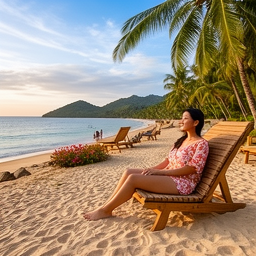

Particle 1  HPSv2=0.2631  weight=0.246


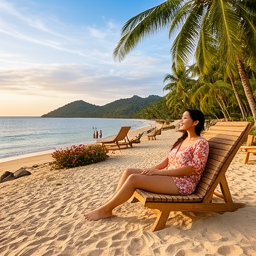

Particle 2  HPSv2=0.2933  weight=0.254


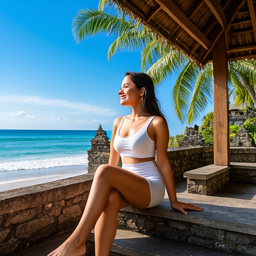

Particle 3  HPSv2=0.2916  weight=0.253


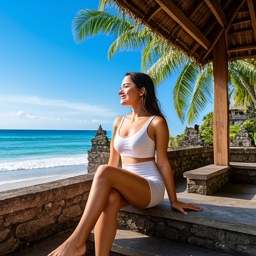

In [3]:
final_weights = torch.softmax(log_weights, dim=0)
for i in range(k):
    score = log_weights[i].item()
    weight = final_weights[i].item()
    print(f"Particle {i}  HPSv2={score:.4f}  weight={weight:.3f}")
    img = decode_and_display(X[i:i+1].to(dtype), X_ids, auto_encoder)
    display(img)